R_L(\Omega),U1(V),I1(mA),U2(V),I2(mA)
inf,7.05,5.07e-6,7.02,9.02e-6
0,2.52e-3,29.2,2.09e-2,28.2
100,2.08,20.7,2.03,20.1
200,3.22,15.9,3.17,15.7
300,3.93,13.0,3.86,12.8
400,4.42,10.8,4.35,10.6
500,4.77,9.36,4.70,9.22
600,5.04,8.28,4.98,8.18
700,5.25,7.40,5.19,7.32
800,5.43,6.68,5.36,6.60
900,5.57,6.10,5.51,6.03
1000,5.69,5.62,5.63,5.56

Fitted line: U = -19.9732 * I + 7.9859


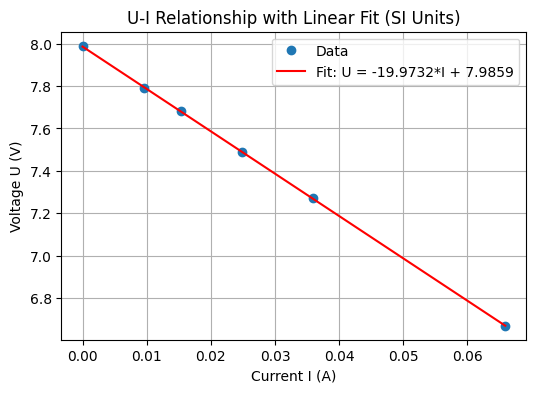

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO
import numpy as np

# Prepare data (SI units: I in A, U in V, R_L in Ohm)
data = '''R_L(Ohm),U(V),I(A)
100,6.67,0.0659
200,7.27,0.0359
300,7.49,0.0248
500,7.68,0.0153
800,7.79,0.00957
inf,7.99,0.00'''
df = pd.read_csv(StringIO(data))

# Least squares linear fit: U = a * I + b
I = df['I(A)'].values
U = df['U(V)'].values
A = np.vstack([I, np.ones(len(I))]).T
a, b = np.linalg.lstsq(A, U, rcond=None)[0]
print(f"Fitted line: U = {a:.4f} * I + {b:.4f}")

# Plot U vs I and fitted line
plt.figure(figsize=(6,4))
plt.plot(I, U, 'o', label='Data')
plt.plot(I, a*I + b, 'r-', label=f'Fit: U = {a:.4f}*I + {b:.4f}')
plt.xlabel('Current I (A)')
plt.ylabel('Voltage U (V)')
plt.title('U-I Relationship with Linear Fit (SI Units)')
plt.legend()
plt.grid(True)
plt.savefig('ui_relationship.png')
plt.show()

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO
import numpy as np

# 准备原始数据
data_raw = '''R_L(Ohm),U1(V),I1(mA),U2(V),I2(mA)
100,2.08,20.7,2.03,20.1
200,3.22,15.9,3.17,15.7
300,3.93,13.0,3.86,12.8
400,4.42,10.8,4.35,10.6
500,4.77,9.36,4.70,9.22
600,5.04,8.28,4.98,8.18
700,5.25,7.40,5.19,7.32
800,5.43,6.68,5.36,6.60
900,5.57,6.10,5.51,6.03
1000,5.69,5.62,5.63,5.56'''

df_raw = pd.read_csv(StringIO(data_raw))

# 转换单位：mA -> A
df_raw['I1(A)'] = df_raw['I1(mA)'] / 1000
df_raw['I2(A)'] = df_raw['I2(mA)'] / 1000

print("原始数据:")
print(df_raw)

原始数据:
   R_L(Ohm)  U1(V)  I1(mA)  U2(V)  I2(mA)    I1(A)    I2(A)
0       100   2.08   20.70   2.03   20.10  0.02070  0.02010
1       200   3.22   15.90   3.17   15.70  0.01590  0.01570
2       300   3.93   13.00   3.86   12.80  0.01300  0.01280
3       400   4.42   10.80   4.35   10.60  0.01080  0.01060
4       500   4.77    9.36   4.70    9.22  0.00936  0.00922
5       600   5.04    8.28   4.98    8.18  0.00828  0.00818
6       700   5.25    7.40   5.19    7.32  0.00740  0.00732
7       800   5.43    6.68   5.36    6.60  0.00668  0.00660
8       900   5.57    6.10   5.51    6.03  0.00610  0.00603
9      1000   5.69    5.62   5.63    5.56  0.00562  0.00556



U1-I1拟合结果:
拟合方程: U1 = -238.9463 * I1 + 7.0212
相关系数 R² = 0.9999


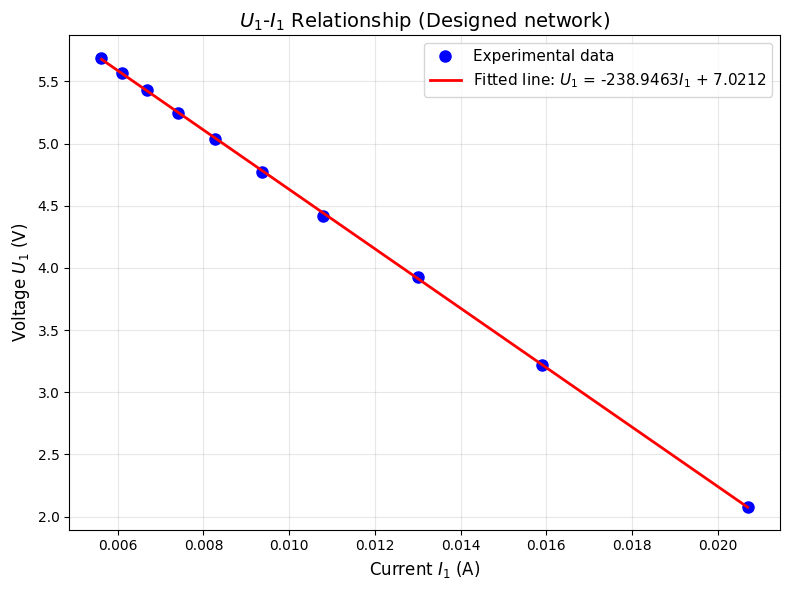

In [18]:
# U1-I1 最小二乘法拟合
I1 = df_raw['I1(A)'].values
U1 = df_raw['U1(V)'].values

# 线性拟合: U1 = a1 * I1 + b1
A1 = np.vstack([I1, np.ones(len(I1))]).T
a1, b1 = np.linalg.lstsq(A1, U1, rcond=None)[0]

print(f"\nU1-I1拟合结果:")
print(f"拟合方程: U1 = {a1:.4f} * I1 + {b1:.4f}")

# 计算相关系数R²
U1_pred = a1 * I1 + b1
ss_res = np.sum((U1 - U1_pred) ** 2)
ss_tot = np.sum((U1 - np.mean(U1)) ** 2)
r_squared_1 = 1 - (ss_res / ss_tot)
print(f"相关系数 R² = {r_squared_1:.4f}")

# 绘制U1-I1关系图
plt.figure(figsize=(8, 6))
plt.plot(I1, U1, 'bo', markersize=8, label='Experimental data')
plt.plot(I1, U1_pred, 'r-', linewidth=2, label=f'Fitted line: $U_1$ = {a1:.4f}$I_1$ + {b1:.4f}')
plt.xlabel('Current $I_1$ (A)', fontsize=12)
plt.ylabel('Voltage $U_1$ (V)', fontsize=12)
plt.title('$U_1$-$I_1$ Relationship (Designed network)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


U2-I2拟合结果:
拟合方程: U2 = -245.4846 * I2 + 6.9846
相关系数 R² = 0.9997


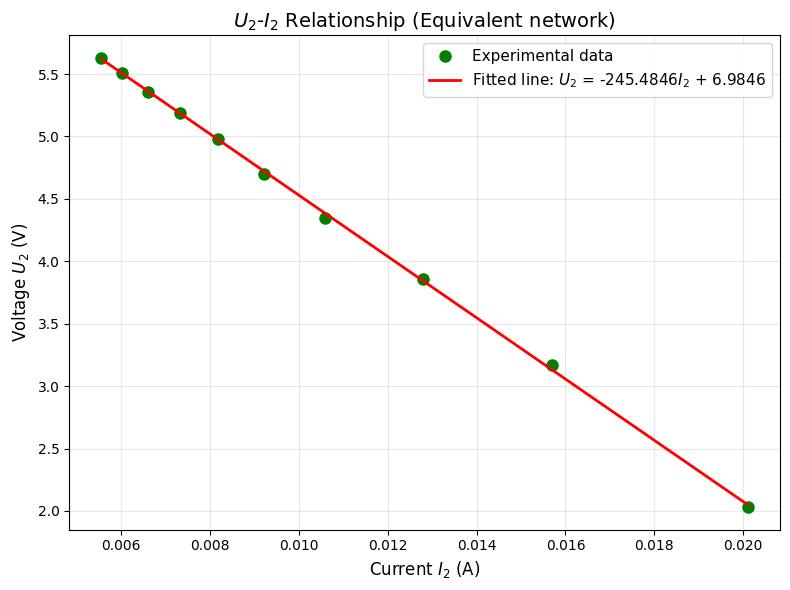

In [19]:
# U2-I2 最小二乘法拟合
I2 = df_raw['I2(A)'].values
U2 = df_raw['U2(V)'].values

# 线性拟合: U2 = a2 * I2 + b2
A2 = np.vstack([I2, np.ones(len(I2))]).T
a2, b2 = np.linalg.lstsq(A2, U2, rcond=None)[0]

print(f"\nU2-I2拟合结果:")
print(f"拟合方程: U2 = {a2:.4f} * I2 + {b2:.4f}")

# 计算相关系数R²
U2_pred = a2 * I2 + b2
ss_res_2 = np.sum((U2 - U2_pred) ** 2)
ss_tot_2 = np.sum((U2 - np.mean(U2)) ** 2)
r_squared_2 = 1 - (ss_res_2 / ss_tot_2)
print(f"相关系数 R² = {r_squared_2:.4f}")

# 绘制U2-I2关系图
plt.figure(figsize=(8, 6))
plt.plot(I2, U2, 'go', markersize=8, label='Experimental data')
plt.plot(I2, U2_pred, 'r-', linewidth=2, label=f'Fitted line: $U_2$ = {a2:.4f}$I_2$ + {b2:.4f}')
plt.xlabel('Current $I_2$ (A)', fontsize=12)
plt.ylabel('Voltage $U_2$ (V)', fontsize=12)
plt.title('$U_2$-$I_2$ Relationship (Equivalent network)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

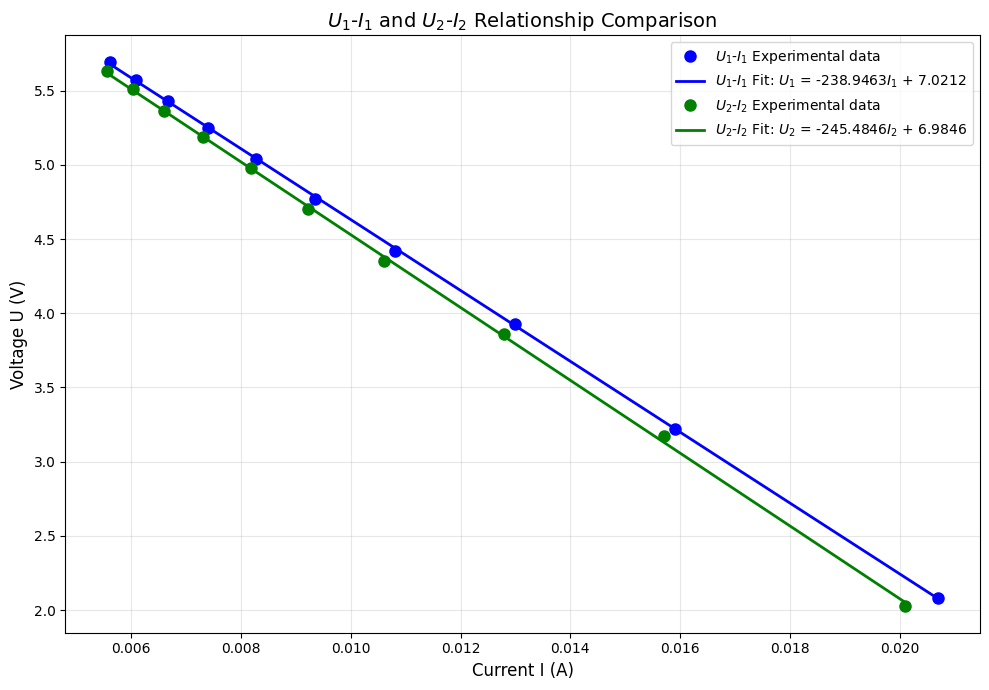


=== 拟合结果总结 ===
U1-I1拟合方程: U1 = -238.9463 * I1 + 7.0212, R² = 0.9999
U2-I2拟合方程: U2 = -245.4846 * I2 + 6.9846, R² = 0.9997

斜率差异: 6.5384
截距差异: 0.0366


In [20]:
# 在同一图中绘制两条拟合直线
plt.figure(figsize=(10, 7))

# 绘制U1-I1数据和拟合线
plt.plot(I1, U1, 'bo', markersize=8, label='$U_1$-$I_1$ Experimental data')
plt.plot(I1, U1_pred, 'b-', linewidth=2, label=f'$U_1$-$I_1$ Fit: $U_1$ = {a1:.4f}$I_1$ + {b1:.4f}')

# 绘制U2-I2数据和拟合线
plt.plot(I2, U2, 'go', markersize=8, label='$U_2$-$I_2$ Experimental data')
plt.plot(I2, U2_pred, 'g-', linewidth=2, label=f'$U_2$-$I_2$ Fit: $U_2$ = {a2:.4f}$I_2$ + {b2:.4f}')

plt.xlabel('Current I (A)', fontsize=12)
plt.ylabel('Voltage U (V)', fontsize=12)
plt.title('$U_1$-$I_1$ and $U_2$-$I_2$ Relationship Comparison ', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 总结拟合结果
print("\n=== 拟合结果总结 ===")
print(f"U1-I1拟合方程: U1 = {a1:.4f} * I1 + {b1:.4f}, R² = {r_squared_1:.4f}")
print(f"U2-I2拟合方程: U2 = {a2:.4f} * I2 + {b2:.4f}, R² = {r_squared_2:.4f}")
print(f"\n斜率差异: {abs(a1-a2):.4f}")
print(f"截距差异: {abs(b1-b2):.4f}")